# Module 8: Static Visualization (Matplotlib & Seaborn)
## Objective: Designing high-fidelity, professional analytical charts.

In this module, we transition from "Data Scientists" to "Data Communicators." 
We will master the Object-Oriented interface of Matplotlib and the 
statistical power of Seaborn to create charts that drive decision-making.

### 1. The Fig and Ax Structure
Instead of letting Python guess where to plot, we explicitly create a 
`Figure` (the container) and `Axes` (the charts). This allows us to 
manipulate subplots with surgical precision.

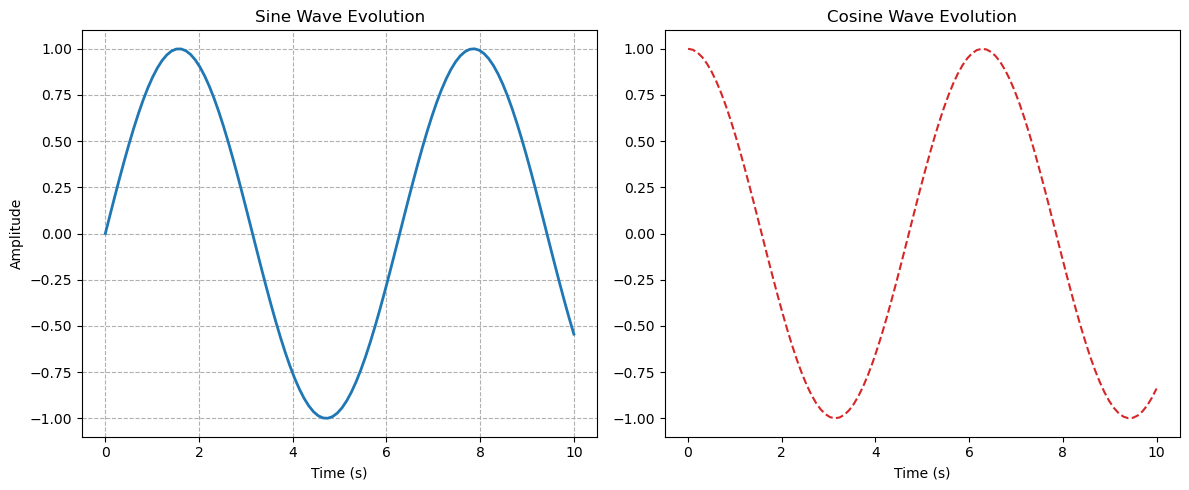

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Synthetic Data
x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.cos(x)

# Create a figure with 2 subplots (1 row, 2 columns)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

# Plot on the first axes
ax[0].plot(x, y1, color='tab:blue', linewidth=2)
ax[0].set_title("Sine Wave Evolution")
ax[0].set_xlabel("Time (s)")
ax[0].set_ylabel("Amplitude")
ax[0].grid(True, linestyle='--')

# Plot on the second axes
ax[1].plot(x, y2, color='tab:red', linestyle='--')
ax[1].set_title("Cosine Wave Evolution")
ax[1].set_xlabel("Time (s)")

# Final adjustments to prevent overlap
plt.tight_layout()
plt.show()

### 2. Statistical Visualization
We use distribution plots to understand the "spread" and "skew" of our data. 
Violin plots are particularly powerful for seeing where most data points "cluster."

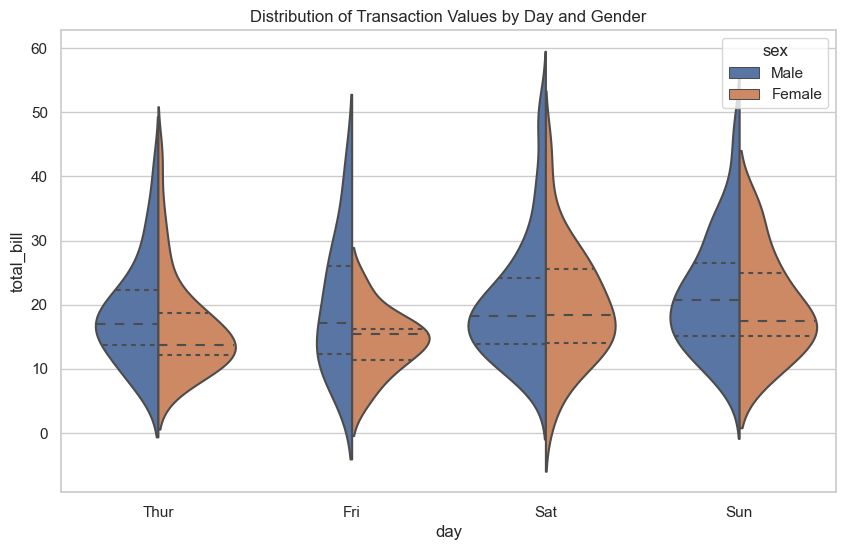

In [2]:
import seaborn as sns
import pandas as pd

# Load a medical-style dataset (e.g., Tips or a health-related sample)
tips = sns.load_dataset('tips')

# Setting a professional theme
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
# A Violin Plot showing distribution of Total Bill by Day
sns.violinplot(data=tips, x='day', y='total_bill', hue='sex', split=True, inner="quart")

plt.title("Distribution of Transaction Values by Day and Gender")
plt.show()

### 3. FacetGrids: The "Multi-Chart" Grid
A FacetGrid maps a dataset onto multiple axes arranged in a grid of rows and columns 
that correspond to levels of variables in the dataset.

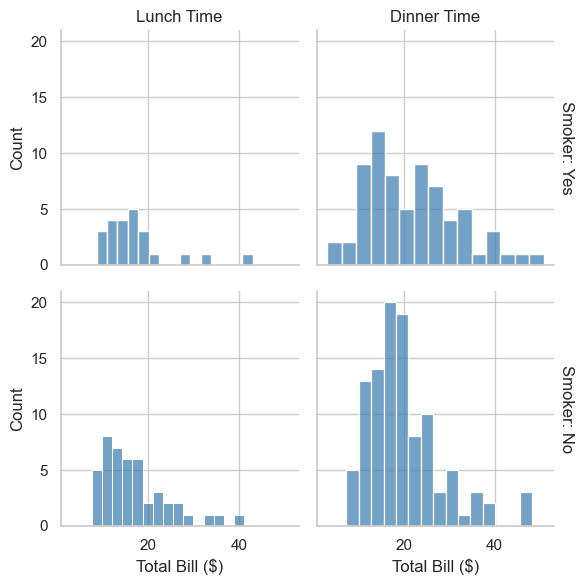

In [3]:
# Create a Grid based on 'Time' (Lunch vs Dinner) and 'Smoker' status
g = sns.FacetGrid(tips, col="time", row="smoker", margin_titles=True)

# Map a histogram to each grid section
g.map(sns.histplot, "total_bill", color="steelblue", bins=15)

# Final Polish
g.set_axis_labels("Total Bill ($)", "Count")
g.set_titles(col_template="{col_name} Time", row_template="Smoker: {row_name}")
plt.show()

### 4. Color Theory in Practice
Choosing the right palette is not just about aesthetics; it's about clarity. 
* **Sequential**: For data that goes from low to high (e.g., Population).
* **Diverging**: For data with a clear midpoint (e.g., Temperature around 0).
* **Colorblind-friendly**: Using 'mako', 'rocket', or 'viridis'.

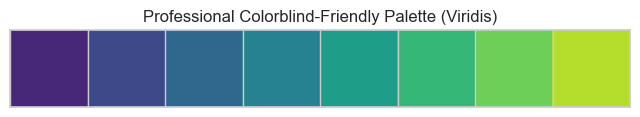

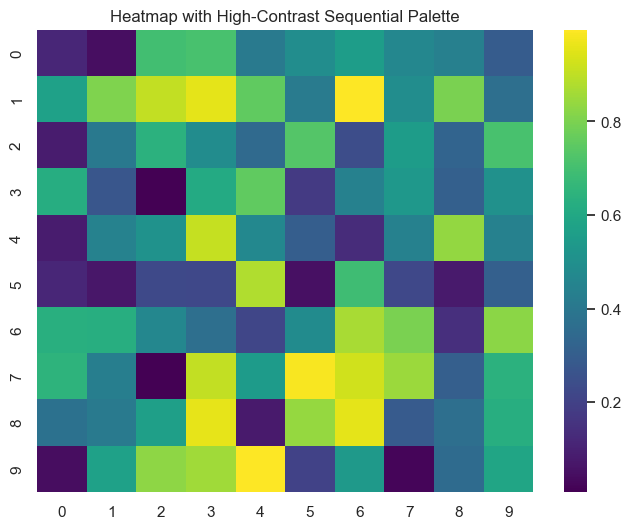

In [4]:
# Displaying a colorblind-friendly palette
current_palette = sns.color_palette("viridis", 8)
sns.palplot(current_palette)
plt.title("Professional Colorblind-Friendly Palette (Viridis)")
plt.show()

# Applying the palette to a heatmap
data = np.random.rand(10, 10)
plt.figure(figsize=(8, 6))
sns.heatmap(data, cmap="viridis", annot=False)
plt.title("Heatmap with High-Contrast Sequential Palette")
plt.show()

### Student Exercise: The Regional Visual Dashboard
**Goal**: Visualize the performance of different regional agricultural sectors.
1. Create a DataFrame with 400 entries:
    - **District**: ('Peshawar', 'Mardan', 'Swat', 'Chasadda').
    - **Crop**: ('Wheat', 'Maize').
    - **Yield**: (Random continuous values).
    - **Month**: (1 through 12).
2. Create a **Figure** with 2 subplots (1 row, 2 columns).
3. On the left: Use a **Box-plot** to compare 'Yield' across the 4 Districts.
4. On the right: Use a **Violin-plot** to see the yield distribution by 'Crop' type.
5. Apply a **Colorblind-friendly** palette to both charts.
6. Bonus: Create a **FacetGrid** showing 'Yield' histograms for each 'District' across the top.